        ip_address  abuse_confidence_score country_code  \
0  213.177.179.113                     100           NL   
1      172.94.9.48                     100           NL   
2    171.25.158.73                     100           SE   
3  213.209.159.235                     100           DE   
4    163.53.168.23                     100           CN   

            last_reported_at country_name continent reported_date  \
0  2026-04-17 18:03:45+00:00  Netherlands    Europe    2026-04-17   
1  2026-04-17 18:03:45+00:00  Netherlands    Europe    2026-04-17   
2  2026-04-17 18:03:45+00:00       Sweden    Europe    2026-04-17   
3  2026-04-17 18:03:45+00:00      Germany    Europe    2026-04-17   
4  2026-04-17 18:03:45+00:00        China      Asia    2026-04-17   

   reported_year  reported_month  reported_day  reported_hour  \
0           2026               4            17             18   
1           2026               4            17             18   
2           2026               4   

/tmp/ipykernel_5494/2041928637.py:45: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)



===== Model Performance =====
Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24


Confusion Matrix:

[[24]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


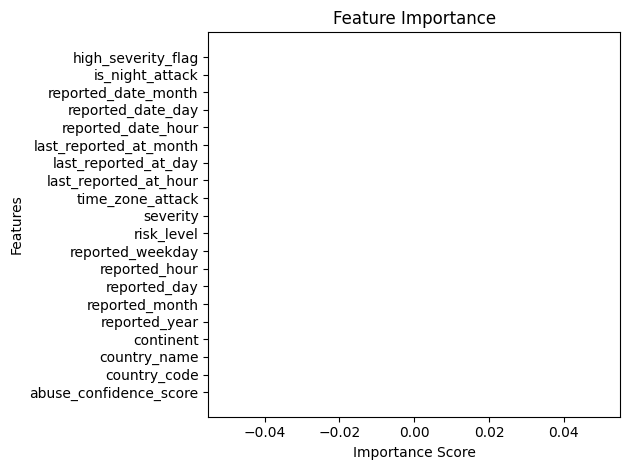


✅ Model & scaler saved successfully!


In [2]:
#  1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE


# 2. Load Dataset
df = pd.read_csv("/content/drive/MyDrive/final_kaggle_cyber_dataset.csv")

print(df.head())
print(df.info())


#  3. Data Cleaning
# Drop useless / high-cardinality columns
if "ip_address" in df.columns:
    df.drop(columns=["ip_address"], inplace=True)

# Convert datetime columns
for col in ["last_reported_at", "reported_date"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])
        df[col + "_hour"] = df[col].dt.hour
        df[col + "_day"] = df[col].dt.day
        df[col + "_month"] = df[col].dt.month
        df.drop(columns=[col], inplace=True)

# Handle missing values (numeric)
df.fillna(df.median(numeric_only=True), inplace=True)

# Handle categorical missing
for col in df.select_dtypes(include="object").columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)


#  4. Feature Engineering
if "reported_hour" in df.columns:
    df["is_night_attack"] = df["reported_hour"].apply(lambda x: 1 if x < 6 or x > 20 else 0)

if "severity" in df.columns:
    df["high_severity_flag"] = (df["severity"] > df["severity"].median()).astype(int)


#  5. Encoding
le_dict = {}

for col in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le


#  6. Features & Target
target = "label"

# Encode target separately
le_target = LabelEncoder()
df[target] = le_target.fit_transform(df[target])
X = df.drop(columns=[target])
y = df[target]
print("\nTarget distribution:\n", np.bincount(y))


#  7. Train-Test Split (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

feature_names = X.columns


# 8. Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


#  9. SMOTE (Safe Handling)
if len(np.unique(y_train)) > 1:
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)
    print("After SMOTE:", np.bincount(y_train))
else:
    print(" SMOTE skipped: only one class present")


#  10. Model Training
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)


#  11. Prediction
y_pred = model.predict(X_test)


#  12. Evaluation
accuracy = accuracy_score(y_test, y_pred)

print("\n===== Model Performance =====")
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


#  13. Feature Importance
importance = model.feature_importances_

plt.figure()
plt.barh(feature_names, importance)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


#  14. Save Model
joblib.dump(model, "cyber_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("\n Model & scaler saved successfully!")